# Business Exploratory Data Analysis

This notebook analyzes geographic revenue concentration, product performance, monthly sales trends, revenue distribution, and relationships between key transaction variables in the cleaned Online Retail dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_clean = pd.read_csv("/content/sample_data/online_retail_cleaned.csv")

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Dataset shape:", df_clean.shape)
df_clean.head()

/tmp/ipykernel_496/2151175493.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("/content/sample_data/online_retail_cleaned.csv")


Dataset shape: (524878, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Top 10 Countries by Revenue

This analysis identifies the markets that generate the highest total revenue and helps assess whether sales are concentrated in a small number of countries.

In [2]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


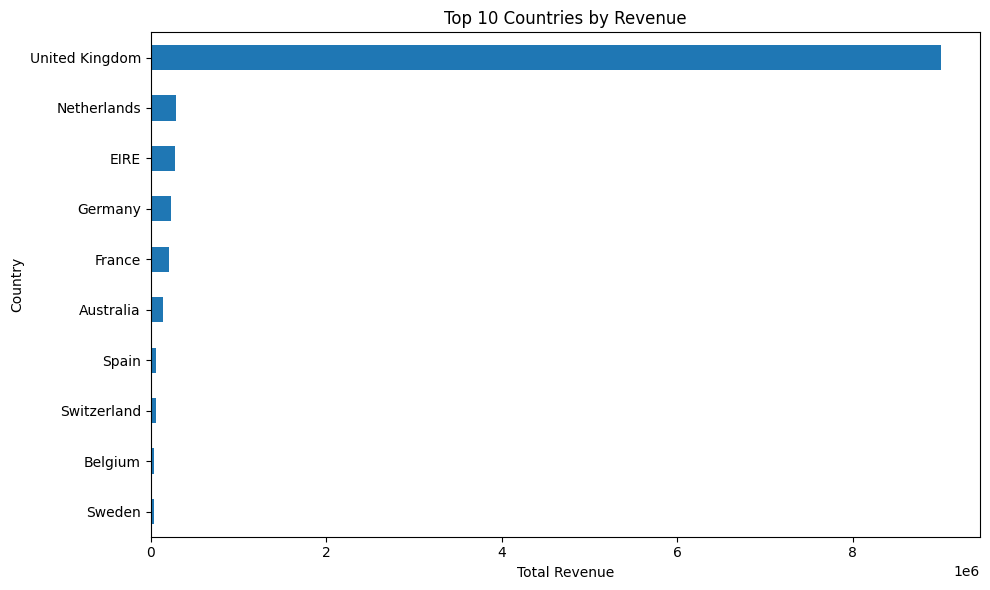

In [7]:
plt.figure(figsize=(10, 6))
country_revenue.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Interpretation: Top 10 Countries by Revenue

The United Kingdom generated by far the highest total revenue among all countries in the dataset. The revenue contribution from the United Kingdom is substantially larger than that of the Netherlands, EIRE, Germany, France, Australia, Spain, Switzerland, Belgium, and Sweden.

This result indicates that the retailer’s sales are highly concentrated in its domestic market. Although several international markets contribute to revenue, their contribution is relatively small compared with the United Kingdom. From a business perspective, this concentration creates both an opportunity and a risk. The United Kingdom should remain the main focus for inventory planning and customer retention, while selected international markets may be examined for growth potential and market diversification.

This finding should be interpreted carefully because the dataset represents one UK-based retailer and covers only a limited time period. Therefore, the results cannot be generalized to the full international retail industry.


In [8]:
uk_revenue_share = (
    df_clean.loc[df_clean["Country"] == "United Kingdom", "Revenue"].sum()
    / df_clean["Revenue"].sum()
) * 100

print(f"United Kingdom revenue share: {uk_revenue_share:.2f}%")

United Kingdom revenue share: 84.59%


* The United Kingdom accounted for approximately 84.59% of total revenue.

## Top 10 Products by Revenue

This analysis identifies the products that generated the highest total revenue and helps support inventory prioritization and merchandising decisions.

In [13]:
non_product_items = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual"
]

product_df = df_clean[
    ~df_clean["Description"].isin(non_product_items)
].copy()

product_revenue = (
    product_df.dropna(subset=["Description"])
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


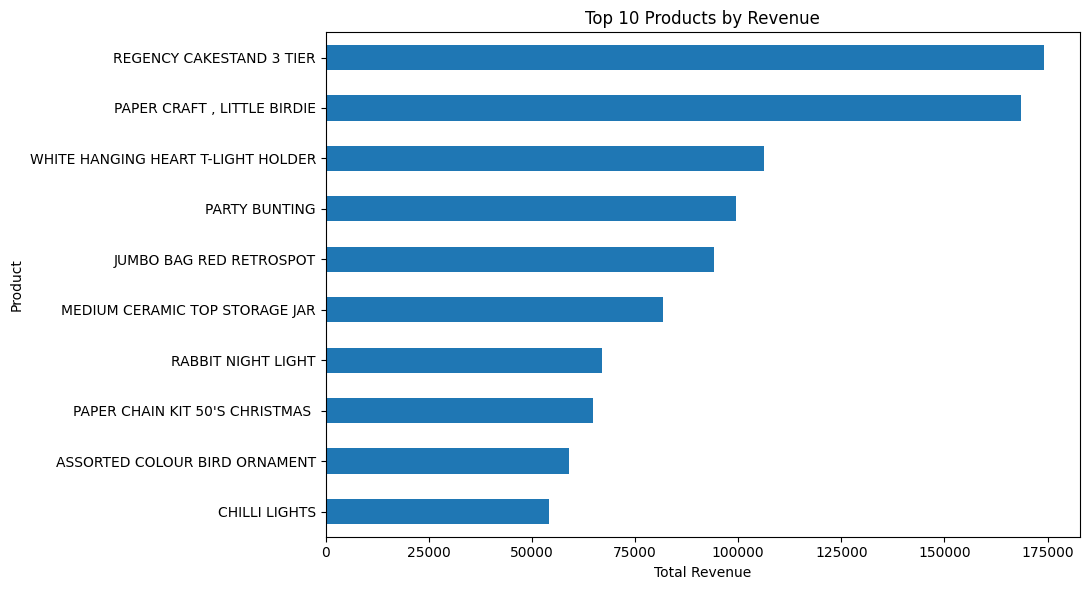

In [14]:
plt.figure(figsize=(11, 6))
product_revenue.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Interpretation: Top 10 Products by Revenue

After excluding non-merchandise entries, **REGENCY CAKESTAND 3 TIER** generated the highest revenue, followed by **PAPER CRAFT, LITTLE BIRDIE** and **WHITE HANGING HEART T-LIGHT HOLDER**. These products may deserve priority in inventory planning and merchandising. However, revenue should be reviewed together with quantity sold and transaction frequency because high revenue may result from high price, high sales volume, or both.


## Monthly Revenue Trend

This analysis examines how total revenue changed over time and helps identify seasonal patterns, growth periods, and possible demand fluctuations.

In [15]:
df_clean["Month"] = pd.to_datetime(df_clean["InvoiceDate"]).dt.to_period("M").astype(str)

monthly_revenue = (
    df_clean.groupby("Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

,Revenue
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


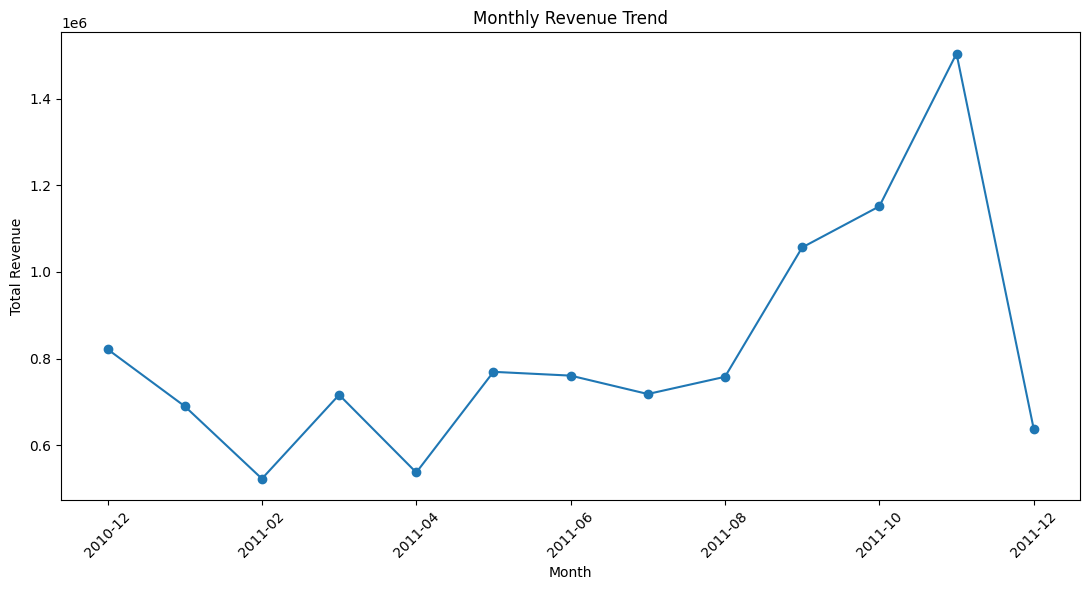

In [16]:
plt.figure(figsize=(11, 6))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation: Monthly Revenue Trend

Monthly revenue fluctuated during the year but increased strongly from August to November 2011. November recorded the highest revenue, suggesting a seasonal increase before the holiday period. The lower revenue shown for December 2011 should be interpreted cautiously because the dataset includes only part of that month.


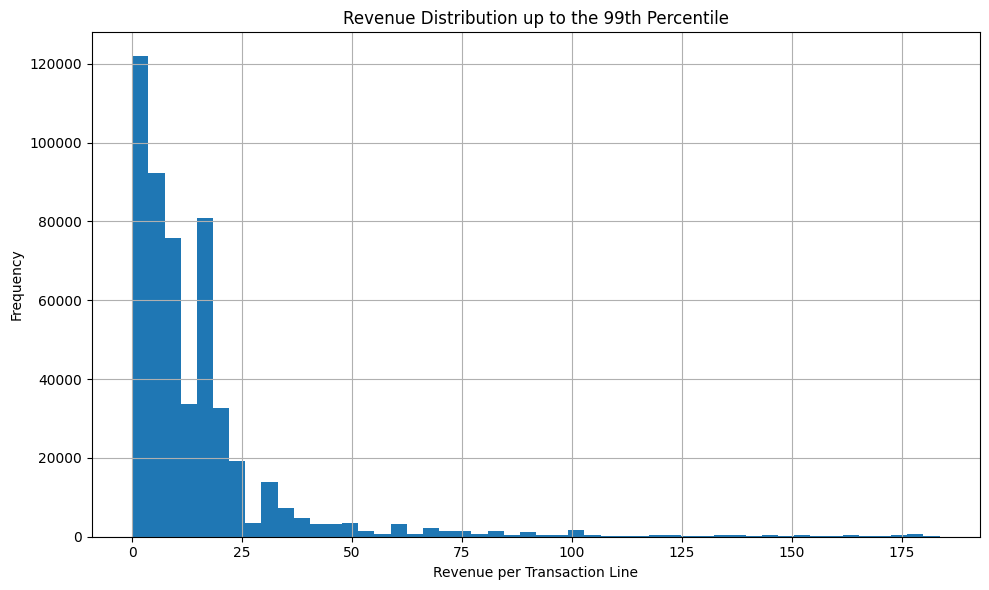

99th percentile revenue: 183.6


In [17]:
#For Revenue Distribution
revenue_cap = df_clean["Revenue"].quantile(0.99)

plt.figure(figsize=(10, 6))
df_clean.loc[df_clean["Revenue"] <= revenue_cap, "Revenue"].hist(bins=50)
plt.title("Revenue Distribution up to the 99th Percentile")
plt.xlabel("Revenue per Transaction Line")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("99th percentile revenue:", revenue_cap)

## Interpretation: Revenue Distribution

Revenue per transaction line is strongly right-skewed. Most transactions generate relatively low revenue, while a small number of transactions generate much higher values. The 99th percentile is 183.60, meaning that 99% of transaction-line revenue values are at or below this amount. This skewness should be considered when interpreting averages and identifying outliers.

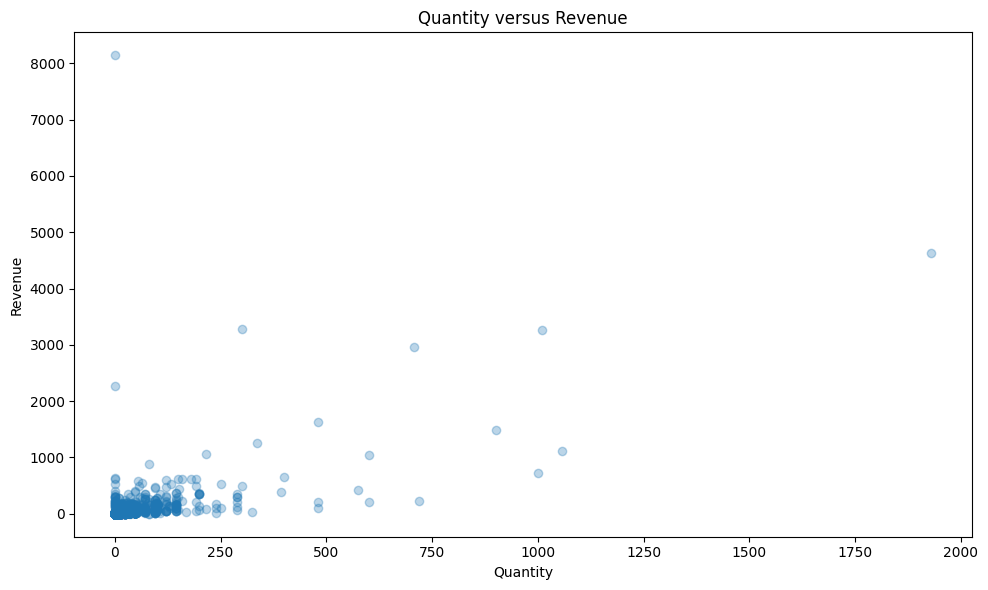

,Quantity,Revenue
Quantity,1.000000,0.907402
Revenue,0.907402,1.000000


In [18]:
# Bivariate Analysis

sample_df = df_clean.sample(
    n=min(10000, len(df_clean)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["Quantity"], sample_df["Revenue"], alpha=0.3)
plt.title("Quantity versus Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

quantity_revenue_corr = df_clean[["Quantity", "Revenue"]].corr()
quantity_revenue_corr

## Interpretation: Quantity versus Revenue

Quantity and revenue have a strong positive correlation of 0.907. This means that transactions with larger quantities generally generate higher revenue. However, the scatter plot also shows several outliers, and some high-revenue transactions occur at lower quantities because unit price also affects revenue. Therefore, quantity is an important driver of revenue, but it should not be considered alone.

In [20]:
price_quantity_corr = df_clean[["UnitPrice", "Quantity"]].corr()
price_quantity_corr

,UnitPrice,Quantity
UnitPrice,1.000000,-0.003788
Quantity,-0.003788,1.000000


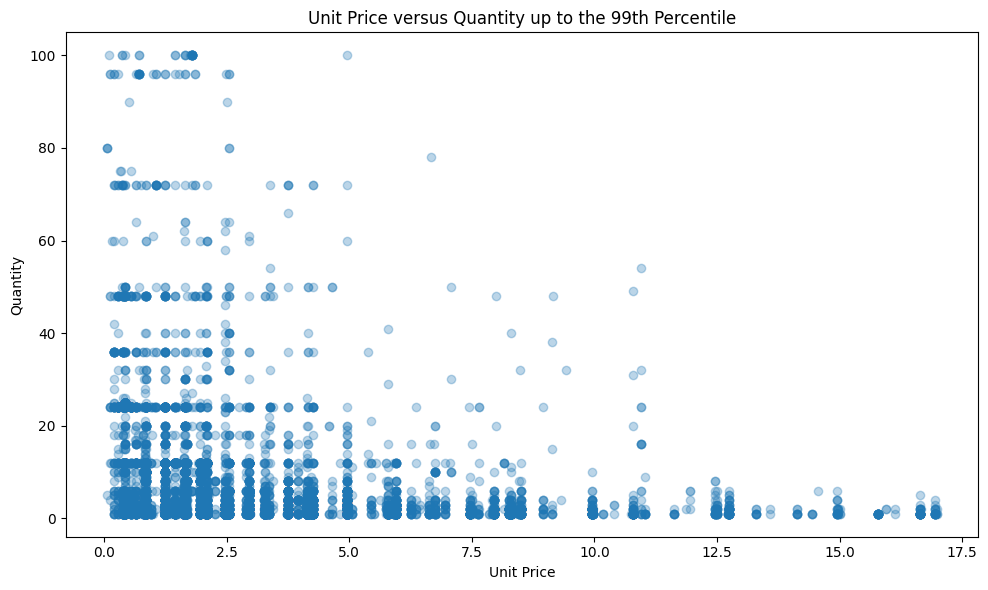

In [21]:
quantity_cap = df_clean["Quantity"].quantile(0.99)
price_cap = df_clean["UnitPrice"].quantile(0.99)

plot_data = df_clean[
    (df_clean["Quantity"] <= quantity_cap) &
    (df_clean["UnitPrice"] <= price_cap)
].sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_data["UnitPrice"], plot_data["Quantity"], alpha=0.3)
plt.title("Unit Price versus Quantity up to the 99th Percentile")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

## Interpretation: Unit Price versus Quantity

The scatter plot suggests that higher-priced products are generally purchased in smaller quantities, while lower-priced products are purchased across a wider range of quantities. The relationship is not perfectly linear, which indicates that purchasing quantity is influenced by other factors such as product type, customer need, and transaction size.

In [22]:
price_quantity_corr = df_clean[["UnitPrice", "Quantity"]].corr()
price_quantity_corr

,UnitPrice,Quantity
UnitPrice,1.000000,-0.003788
Quantity,-0.003788,1.000000


## Interpretation: Unit Price versus Quantity

The correlation between unit price and quantity is approximately −0.004, indicating almost no linear relationship between the two variables. Although the scatter plot shows that many high-priced items are purchased in small quantities, the overall relationship is too weak to support a strong conclusion. Purchase quantity is likely influenced by other factors such as product type, customer needs, and order size.